<a href="https://colab.research.google.com/github/yariela-carvajal/Sesion2IA/blob/main/Copia_de_Sesion2IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 2 — Datos, Librerías IA y Prompting Avanzado

**Módulo: Python para IA** | Máster en Inteligencia Artificial

## Objetivos de esta sesión

- Conocer **NumPy** y **Pandas**: las librerías fundamentales para datos en Python.
- Dominar técnicas de **prompting avanzado**: Chain of Thought, Role Prompting, System Prompts.
- Entender el **desarrollo agéntico**: qué son los agentes para desarrollo y cómo usar GitHub Copilot.
- Construir una **red neuronal con Keras** guiada por prompts.

> 💡 **Recuerda**: no necesitas memorizar la API de cada librería. Necesitas saber *qué hace* y *cómo pedírselo a la IA*.

### Contexto: de los fundamentos al ecosistema real

En la Sesión 1 aprendimos los fundamentos de Python y los principios del prompting. En esta sesión damos el salto al **ecosistema real de la IA**: las librerías que usaréis a diario (NumPy, Pandas, Keras), las técnicas de prompting que marcan la diferencia entre un prompt mediocre y uno profesional, y las herramientas de desarrollo asistido por IA que están transformando la industria.

Al final de esta sesión seréis capaces de:
1. Manipular datos numéricos y tabulares con NumPy y Pandas.
2. Escribir prompts avanzados que producen código de calidad profesional.
3. Usar GitHub Copilot como asistente de desarrollo.
4. Construir y entrenar vuestra primera red neuronal.

---
# Bloque 1 — NumPy y Pandas Express (15 min)

Estas dos librerías son la **base de todo el ecosistema de datos y Machine Learning en Python**. Prácticamente cualquier proyecto de IA las usa, directa o indirectamente:

- **NumPy** maneja los arrays numéricos internos de TensorFlow, PyTorch, Scikit-learn...
- **Pandas** es la herramienta estándar para cargar, limpiar y explorar datos antes de alimentar un modelo.

El objetivo de este bloque no es que dominéis cada función — eso lo haréis progresivamente a lo largo del Máster. El objetivo es que entendáis **qué hacen** y **cuándo usarlas**, para que podáis pedirle a la IA operaciones concretas: *"calcula la media por grupo"*, *"normaliza esta columna"*, *"reshapea este array a 3 dimensiones"*.

## NumPy — La Base Numérica

**NumPy** (Numerical Python) es la librería fundamental para cálculo numérico en Python. Proporciona **arrays multidimensionales eficientes** y **operaciones vectorizadas** que son órdenes de magnitud más rápidas que los bucles nativos de Python.

### ¿Por qué no usar listas normales de Python?

Una lista de Python es muy flexible (puede mezclar tipos: `[1, "hola", True]`), pero esa flexibilidad tiene un coste: es **lenta para cálculos numéricos**. NumPy resuelve esto con arrays que:

- Almacenan datos del **mismo tipo** (todos `float`, todos `int`...) en memoria contigua.
- Permiten **operaciones vectorizadas**: en vez de un bucle `for` para sumar dos arrays, NumPy lo hace internamente en C, miles de veces más rápido.
- Soportan **broadcasting**: operaciones entre arrays de diferentes tamaños se resuelven automáticamente.

### Conceptos clave — Dimensiones de arrays

En el mundo de la IA, trabajaréis constantemente con arrays de diferentes dimensiones. Es crucial entender la terminología:

| Concepto | Dimensiones | Ejemplo | En IA se usa para... |
|----------|-------------|---------|---------------------|
| **Scalar** | 0D | `5` | Un valor individual (loss, accuracy) |
| **Vector** | 1D | `[1, 2, 3]` | Una muestra de features, embeddings |
| **Matriz** | 2D | `[[1,2],[3,4]]` | Dataset tabular, pesos de una capa |
| **Tensor 3D** | 3D | Cubo de números | Secuencias (texto), imágenes en escala de grises |
| **Tensor 4D** | 4D | Batch de imágenes | Batch de imágenes RGB (batch, alto, ancho, canales) |

El término **"shape"** describe las dimensiones de un array. Por ejemplo, `shape=(60000, 28, 28)` significa 60.000 imágenes de 28×28 píxeles — exactamente lo que veremos con el dataset MNIST más adelante.

> 🤖 **Para el prompting**: cuando trabajes con datos numéricos, especifica siempre el shape esperado: *"recibe un array de shape (n, 3) donde cada fila es un punto 3D"*.

In [2]:
import numpy as np

# Crear arrays
vector = np.array([1, 2, 3, 4, 5])
matriz = np.array([[1, 2, 3], [4, 5, 6]])
tensor_3d = np.random.randn(2, 3, 4)  # 2 matrices de 3x4

print(f"Vector: {vector} → shape: {vector.shape}")
print(f"Matriz:{matriz} → shape: {matriz.shape}")
print(f"Tensor 3D shape: {tensor_3d.shape}")

# Operaciones vectorizadas (sin bucles!)
print(f"Vector * 2: {vector * 2}")
print(f"Vector ** 2: {vector ** 2}")
print(f"Media: {vector.mean():.1f}")
print(f"Suma: {vector.sum()}")

# Crear arrays especiales
print(f"Zeros: {np.zeros(5)}")
print(f"Rango: {np.arange(0, 10, 2)}")
print(f"Linspace: {np.linspace(0, 1, 5)}")

# Broadcasting — operar arrays de diferente tamaño
print(f"Matriz + 10:{matriz + 10}")

Vector: [1 2 3 4 5] → shape: (5,)
Matriz:[[1 2 3]
 [4 5 6]] → shape: (2, 3)
Tensor 3D shape: (2, 3, 4)
Vector * 2: [ 2  4  6  8 10]
Vector ** 2: [ 1  4  9 16 25]
Media: 3.0
Suma: 15
Zeros: [0. 0. 0. 0. 0.]
Rango: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]
Matriz + 10:[[11 12 13]
 [14 15 16]]


## Pandas — DataFrames para todo

**Pandas** es como una hoja de cálculo de Excel potenciada con Python. La estructura central es el **DataFrame**: una tabla con filas y columnas nombradas donde cada columna puede tener un tipo diferente (números, texto, fechas, booleanos...).

### ¿Por qué Pandas y no Excel?

- **Escala**: Excel empieza a fallar con más de 100.000 filas. Pandas maneja millones sin problema.
- **Reproducibilidad**: un script de Pandas se puede ejecutar miles de veces con los mismos resultados. En Excel, los pasos manuales no se registran.
- **Integración**: Pandas se conecta directamente con bases de datos, APIs, archivos CSV/JSON/Parquet, y con todo el ecosistema de ML (Scikit-learn, TensorFlow...).
- **Automatización**: puedes encadenar operaciones complejas en pocas líneas de código.

### Operaciones que usaréis constantemente

| Operación | Método | Para qué |
|-----------|--------|----------|
| Cargar datos | `pd.read_csv()`, `pd.read_json()` | Leer archivos |
| Inspeccionar | `.head()`, `.info()`, `.describe()` | Entender los datos |
| Filtrar | `df[df["col"] > valor]` | Seleccionar filas que cumplan condiciones |
| Agrupar | `.groupby("col").mean()` | Estadísticas por grupo |
| Ordenar | `.sort_values("col")` | Reordenar filas |
| Añadir columna | `df["nueva"] = ...` | Crear variables calculadas |
| Eliminar | `.drop(columns=["col"])` | Quitar columnas innecesarias |
| Valores nulos | `.isna()`, `.fillna()`, `.dropna()` | Gestionar datos faltantes |

> 💡 **No memoriréis todo esto** — Pandas tiene cientos de métodos. Lo importante es saber qué operaciones son posibles para poder pedírselas a Gemini: *"agrupa por categoría y calcula la media y desviación estándar del precio"*.

In [3]:
import pandas as pd

# Crear DataFrame desde diccionario
datos = {
    "nombre": ["Ana", "Luis", "María", "Pedro", "Sara"],
    "edad": [22, 25, 23, 28, 21],
    "nota": [8.5, 3.2, 9.1, 6.8, 8.9],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla", "Barcelona"]
}
df = pd.DataFrame(datos)
print("DataFrame completo:")
print(df)
print(f"Shape: {df.shape}")  # (filas, columnas)

DataFrame completo:
  nombre  edad  nota     ciudad
0    Ana    22   8.5     Madrid
1   Luis    25   3.2  Barcelona
2  María    23   9.1     Madrid
3  Pedro    28   6.8    Sevilla
4   Sara    21   8.9  Barcelona
Shape: (5, 4)


In [4]:
# Operaciones esenciales de Pandas

# 1. Estadísticas rápidas
print("=== Estadísticas ===")
print(df.describe())

# 2. Filtrado
print("=== Notas >= 8 ===")
print(df[df["nota"] >= 8])

# 3. Groupby
print("=== Media por ciudad ===")
print(df.groupby("ciudad")["nota"].mean())

# 4. Ordenar
print("=== Ordenado por nota (descendente) ===")
print(df.sort_values("nota", ascending=False))

# 5. Añadir columna calculada
df["aprobado"] = df["nota"] >= 5
print("=== Con columna aprobado ===")
print(df)

=== Estadísticas ===
            edad      nota
count   5.000000  5.000000
mean   23.800000  7.300000
std     2.774887  2.464752
min    21.000000  3.200000
25%    22.000000  6.800000
50%    23.000000  8.500000
75%    25.000000  8.900000
max    28.000000  9.100000
=== Notas >= 8 ===
  nombre  edad  nota     ciudad
0    Ana    22   8.5     Madrid
2  María    23   9.1     Madrid
4   Sara    21   8.9  Barcelona
=== Media por ciudad ===
ciudad
Barcelona    6.05
Madrid       8.80
Sevilla      6.80
Name: nota, dtype: float64
=== Ordenado por nota (descendente) ===
  nombre  edad  nota     ciudad
2  María    23   9.1     Madrid
4   Sara    21   8.9  Barcelona
0    Ana    22   8.5     Madrid
3  Pedro    28   6.8    Sevilla
1   Luis    25   3.2  Barcelona
=== Con columna aprobado ===
  nombre  edad  nota     ciudad  aprobado
0    Ana    22   8.5     Madrid      True
1   Luis    25   3.2  Barcelona     False
2  María    23   9.1     Madrid      True
3  Pedro    28   6.8    Sevilla      True
4   S

### 🛠️ Ejercicio — Análisis con Gemini

Pide a Gemini:

> *"Genera un DataFrame de Pandas con datos de 10 productos (nombre, categoría, precio, stock) y realiza un análisis exploratorio: estadísticas descriptivas, precio medio por categoría, productos con stock bajo (<5), y ordena por precio descendente."*

Pega el resultado y ejecútalo:

In [ ]:
# Pega aquí el código generado por Gemini para el análisis de productos


In [6]:
import pandas as pd

# 1. Crear el DataFrame con 10 productos
datos_productos = {
    "nombre": ["Laptop", "Mouse", "Teclado", "Monitor", "Webcam", "Auriculares", "SSD", "RAM", "GPU", "CPU"],
    "categoría": ["Electrónica", "Accesorios", "Accesorios", "Electrónica", "Accesorios", "Audio", "Almacenamiento", "Componentes", "Componentes", "Componentes"],
    "precio": [999.99, 25.50, 45.00, 199.99, 59.90, 89.00, 120.00, 75.00, 450.00, 320.00],
    "stock": [4, 15, 20, 3, 10, 2, 8, 12, 1, 6]
}

df_productos = pd.DataFrame(datos_productos)
print(df_productos)

# 2. Análisis Exploratorio
print("=== Estadísticas Descriptivas ===")
print(df_productos.describe())

print("\n=== Precio Medio por Categoría ===")
print(df_productos.groupby("categoría")["precio"].mean())

print("\n=== Productos con Stock Bajo (< 5) ===")
stock_bajo = df_productos[df_productos["stock"] < 5]
print(stock_bajo)

print("\n=== Productos Ordenados por Precio (Descendente) ===")
print(df_productos.sort_values("precio", ascending=False))

        nombre       categoría  precio  stock
0       Laptop     Electrónica  999.99      4
1        Mouse      Accesorios   25.50     15
2      Teclado      Accesorios   45.00     20
3      Monitor     Electrónica  199.99      3
4       Webcam      Accesorios   59.90     10
5  Auriculares           Audio   89.00      2
6          SSD  Almacenamiento  120.00      8
7          RAM     Componentes   75.00     12
8          GPU     Componentes  450.00      1
9          CPU     Componentes  320.00      6
=== Estadísticas Descriptivas ===
           precio     stock
count   10.000000  10.00000
mean   238.438000   8.10000
std    300.103401   6.17252
min     25.500000   1.00000
25%     63.675000   3.25000
50%    104.500000   7.00000
75%    289.997500  11.50000
max    999.990000  20.00000

=== Precio Medio por Categoría ===
categoría
Accesorios         43.466667
Almacenamiento    120.000000
Audio              89.000000
Componentes       281.666667
Electrónica       599.990000
Name: precio, dty

---
# Bloque 2 — Prompting Avanzado para Desarrollo (25 min)

En la Sesión 1 vimos los fundamentos del prompting: instrucción clara, contexto, especificaciones, restricciones y ejemplos. Ahora vamos a ver **técnicas avanzadas** que provienen de la investigación en Prompt Engineering y que os permitirán generar código significativamente mejor.

### ¿Por qué importan estas técnicas?

La diferencia entre un prompt básico y uno con técnicas avanzadas es similar a la diferencia entre pedirle a alguien *"hazme una casa"* vs darle unos **planos detallados con especificaciones**. Los modelos de lenguaje son extremadamente sensibles a la forma en que les planteas el problema: un pequeño cambio en el prompt puede cambiar completamente la calidad y la estructura del código generado.

Las técnicas que vamos a ver (Chain of Thought, Role Prompting, System Prompts) son las mismas que usan internamente herramientas como GitHub Copilot, Cursor y otros asistentes de codificación para obtener resultados óptimos.

## Técnicas Avanzadas de Prompting

### 1. Chain of Thought (CoT) — Razonamiento paso a paso

**Chain of Thought** es una de las técnicas más investigadas y efectivas en la literatura de prompting (Wei et al., 2022). La idea es simple pero poderosa: **pedir al modelo que razone antes de dar la respuesta final**.

¿Por qué funciona? Los modelos de lenguaje generan texto token a token. Cuando les pides que "piensen en voz alta", el razonamiento intermedio les proporciona contexto adicional que mejora la calidad de la respuesta final. Es como la diferencia entre resolver un examen de cabeza vs escribir los pasos intermedios.

```
❌ Prompt sin CoT:
"Crea una función que encuentre el camino más corto en un grafo"

✅ Prompt con CoT:
"Necesito encontrar el camino más corto en un grafo con pesos positivos.
 Primero, explica qué algoritmo es más adecuado y por qué.
 Luego, describe los pasos del algoritmo en pseudocódigo.
 Finalmente, implementa el algoritmo en Python con type hints."
```

El resultado con CoT será mucho más robusto: la IA elegirá Dijkstra (o A*), explicará su razonamiento, y el código resultante será más correcto porque ha "pensado" en la estructura antes de escribir.

### 2. Role Prompting — Asignar un rol al modelo

Al dar un **rol** al modelo, cambias su "perspectiva" y el nivel de detalle, terminología y estilo de su respuesta. Es especialmente útil cuando necesitas código con un nivel de calidad específico:

```
✅ "Eres un desarrollador Python senior con 10 años de experiencia en data science.
    Revisa este código y sugiere mejoras siguiendo las mejores prácticas:
    PEP 8, manejo de errores, eficiencia y legibilidad."
```

Otros roles útiles:
- *"Eres un experto en seguridad informática — revisa este código en busca de vulnerabilidades"*
- *"Eres un profesor de Python que explica a principiantes — explica este código paso a paso"*
- *"Eres un ingeniero de MLOps — convierte este notebook en un script de producción"*

### 3. System Prompt — Instrucciones generales persistentes

En las APIs de LLMs (lo veremos con Gemini en la Sesión 3), puedes definir un **system prompt** que establece el comportamiento general del modelo para toda la conversación. Es como darle un "briefing" antes de empezar:

```
System: "Eres un asistente de programación Python especializado en IA.
         Siempre incluye type hints y docstrings estilo Google.
         Si el usuario no especifica manejo de errores, inclúyelo igualmente.
         Responde siempre en español."
```

El system prompt es lo que diferencia a un chatbot genérico de uno especializado. Herramientas como GitHub Copilot usan system prompts enormes internamente para que el modelo se comporte como un asistente de desarrollo.

> 💡 **En Colab**: Gemini no expone directamente el system prompt, pero puedes simular el efecto incluyendo las instrucciones al inicio de tu conversación: *"A partir de ahora, siempre que me generes código, incluye type hints y tests"*.

## Prompting para Tareas Específicas

Según el tipo de tarea que necesites, el prompt debe tener una estructura ligeramente diferente. Aquí tenéis plantillas para las tareas más comunes en desarrollo:

### 🔨 Generar código desde cero

La clave es ser **lo más específico posible** con los inputs, outputs y restricciones:

```
"Crea una clase Python `GestorInventario` que:
- Almacene productos como diccionarios {nombre, precio, stock}
- Tenga métodos: agregar_producto, eliminar_producto, buscar_producto, actualizar_stock
- Valide que precio y stock no sean negativos
- Tenga un método resumen() que devuelva estadísticas del inventario
- Use type hints y docstrings"
```

### 🐛 Debugging — Encontrar y corregir errores

Para debugging, proporciona siempre tres cosas: el **código**, el **error**, y qué **esperabas** que ocurriera:

```
"Tengo este error al ejecutar mi código:
[pega el traceback completo]

El código es:
[pega el código relevante]

Esperaba que devolviera X pero en su lugar hace Y.
Explica por qué ocurre el error y cómo solucionarlo."
```

### 🔄 Refactoring — Mejorar código existente

Al refactorizar, especifica **qué quieres mejorar** (legibilidad, eficiencia, modularidad) y **qué no debe cambiar** (la interfaz pública, los tests):

```
"Refactoriza este código para que sea más legible y eficiente.
Mantén la misma interfaz pública (mismos nombres de funciones y parámetros).
Explica cada cambio que hagas y por qué.


[pega el código]"
```

### 📝 Documentación y tests

```
"Para el siguiente código, genera:
1. Docstrings estilo Google para cada función y clase.
2. Al menos 3 tests unitarios con pytest que cubran: caso normal, caso límite y caso de error.

[pega el código]"
```

> 🔑 **Patrón general**: cuanto más contexto des sobre tu intención, mejores serán los resultados. *"Quiero optimizar esta función porque se ejecuta 10.000 veces por segundo en producción"* produce resultados muy diferentes a *"optimiza esto"*.

## 🛠️ Ejercicio Guiado — Crear una Clase con Prompting Iterativo

Vamos a crear una clase `GestorInventario` completa usando prompting paso a paso. Sigue estas instrucciones con Gemini:

**Iteración 1** — Estructura básica:
> *"Crea una clase `GestorInventario` en Python con un constructor que inicialice una lista vacía de productos"*

**Iteración 2** — Añadir productos:
> *"Añade un método `agregar_producto(nombre, precio, stock)` que añada un diccionario a la lista. Valida que precio y stock sean positivos."*

**Iteración 3** — Búsqueda y eliminación:
> *"Añade métodos `buscar_producto(nombre)` que devuelva el producto o None, y `eliminar_producto(nombre)` que lo elimine si existe."*

**Iteración 4** — Resumen estadístico:
> *"Añade un método `resumen()` que devuelva: número de productos, valor total del inventario (precio*stock por producto), producto más caro y producto con menos stock."*

**Iteración 5** — Type hints y docstrings:
> *"Añade type hints a todos los métodos y docstrings estilo Google. Además añade un método `__repr__` representativo."*

In [9]:
# Pega aquí el resultado de tu prompting iterativo

# Este es un ejemplo de lo que debería salir al final:
class GestorInventario:
    """Gestiona un inventario de productos.

    Attributes:
        productos: Lista de diccionarios con los productos del inventario.
    """

    def __init__(self) -> None:
        """Inicializa el gestor con una lista vacía de productos."""
        self.productos: list[dict] = []

    def agregar_producto(self, nombre: str, precio: float, stock: int) -> None:
        """Añade un producto al inventario.

        Args:
            nombre: Nombre del producto.
            precio: Precio unitario (debe ser positivo).
            stock: Cantidad en stock (debe ser positivo).

        Raises:
            ValueError: Si precio o stock no son positivos.
        """
        if precio <= 0 or stock < 0:
            raise ValueError("Precio debe ser positivo y stock no negativo")
        self.productos.append({"nombre": nombre, "precio": precio, "stock": stock})

    def buscar_producto(self, nombre: str) -> dict | None:
        """Busca un producto por nombre."""
        for p in self.productos:
            if p["nombre"].lower() == nombre.lower():
                return p
        return None

    def eliminar_producto(self, nombre: str) -> bool:
        """Elimina un producto por nombre. Devuelve True si se eliminó."""
        producto = self.buscar_producto(nombre)
        if producto:
            self.productos.remove(producto)
            return True
        return False

    def resumen(self) -> dict:
        """Devuelve estadísticas del inventario."""
        if not self.productos:
            return {"total_productos": 0, "valor_total": 0, "mas_caro": None, "menos_stock": None}

        valor_total = sum(p["precio"] * p["stock"] for p in self.productos)
        mas_caro = max(self.productos, key=lambda p: p["precio"])
        menos_stock = min(self.productos, key=lambda p: p["stock"])

        return {
            "total_productos": len(self.productos),
            "valor_total": round(valor_total, 2),
            "mas_caro": mas_caro["nombre"],
            "menos_stock": menos_stock["nombre"]
        }

    def __repr__(self) -> str:
        return f"GestorInventario({len(self.productos)} productos)"

# Prueba
inventario = GestorInventario()
inventario.agregar_producto("Laptop", 999.99, 5)
inventario.agregar_producto("Mouse", 29.99, 50)
inventario.agregar_producto("Teclado", 79.99, 15)
inventario.agregar_producto("Monitor", 349.99, 3)

print(inventario)
print(f"Búsqueda 'Mouse': {inventario.buscar_producto('Mouse')}")
print(f"Resumen: {inventario.resumen()}")

GestorInventario(4 productos)
Búsqueda 'Mouse': {'nombre': 'Mouse', 'precio': 29.99, 'stock': 50}
Resumen: {'total_productos': 4, 'valor_total': 8749.27, 'mas_caro': 'Laptop', 'menos_stock': 'Monitor'}


In [14]:
class GestorInventario:
    """Gestiona un inventario de productos.

    Attributes:
        productos: Lista de diccionarios con los productos del inventario.
    """

    def __init__(self) -> None:
        """Inicializa el gestor con una lista vacía de productos."""
        self.productos: list[dict] = []

    def agregar_producto(self, nombre: str, precio: float, stock: int) -> None:
        """Añade un producto al inventario.

        Args:
            nombre: Nombre del producto.
            precio: Precio unitario (debe ser positivo).
            stock: Cantidad en stock (debe ser no negativo).

        Raises:
            ValueError: Si precio no es positivo o stock es negativo.
        """
        if precio <= 0:
            raise ValueError("El precio debe ser positivo.")
        if stock < 0:
            raise ValueError("El stock no puede ser negativo.")
        self.productos.append({"nombre": nombre, "precio": precio, "stock": stock})

    def buscar_producto(self, nombre: str) -> dict | None:
        """Busca un producto por nombre (ignorando mayúsculas/minúsculas).

        Args:
            nombre: Nombre del producto a buscar.

        Returns:
            El diccionario del producto si se encuentra, None en caso contrario.
        """
        for p in self.productos:
            if p["nombre"].lower() == nombre.lower():
                return p
        return None

    def eliminar_producto(self, nombre: str) -> bool:
        """Elimina un producto por nombre.

        Args:
            nombre: Nombre del producto a eliminar.

        Returns:
            True si el producto fue eliminado, False si no se encontró.
        """
        producto_a_eliminar = self.buscar_producto(nombre)
        if producto_a_eliminar:
            self.productos.remove(producto_a_eliminar)
            return True
        return False

    def actualizar_stock(self, nombre: str, cantidad: int) -> bool:
        """Actualiza el stock de un producto existente.

        Args:
            nombre: Nombre del producto cuyo stock se va a actualizar.
            cantidad: La nueva cantidad de stock (debe ser no negativa).

        Returns:
            True si el stock fue actualizado, False si el producto no se encontró.

        Raises:
            ValueError: Si la cantidad de stock es negativa.
        """
        if cantidad < 0:
            raise ValueError("La cantidad de stock no puede ser negativa.")

        producto = self.buscar_producto(nombre)
        if producto:
            producto["stock"] = cantidad
            return True
        return False

    def resumen(self) -> dict:
        """Genera un resumen estadístico del inventario.

        Returns:
            Un diccionario con:
            - total_productos: Número total de productos únicos.
            - valor_total_inventario: Valor monetario total de todos los productos.
            - producto_mas_caro: Nombre del producto con el precio más alto.
            - producto_con_menos_stock: Nombre del producto con la menor cantidad en stock.
            Retorna valores por defecto si el inventario está vacío.
        """
        if not self.productos:
            return {
                "total_productos": 0,
                "valor_total_inventario": 0.0,
                "producto_mas_caro": None,
                "producto_con_menos_stock": None
            }

        total_productos = len(self.productos)
        valor_total_inventario = sum(p["precio"] * p["stock"] for p in self.productos)
        producto_mas_caro = max(self.productos, key=lambda p: p["precio"])["nombre"]
        producto_con_menos_stock = min(self.productos, key=lambda p: p["stock"])["nombre"]

        return {
            "total_productos": total_productos,
            "valor_total_inventario": round(valor_total_inventario, 2),
            "producto_mas_caro": producto_mas_caro,
            "producto_con_menos_stock": producto_con_menos_stock
        }

    def __repr__(self) -> str:
        """Representación de cadena para el objeto GestorInventario."""
        return f"GestorInventario({len(self.productos)} productos)"


# --- Demostración de uso y tests básicos ---
print("--- Inicializando GestorInventario ---")
inventario = GestorInventario()
print(f"Inventario inicial: {inventario}")
assert inventario.resumen() == {'total_productos': 0, 'valor_total_inventario': 0.0, 'producto_mas_caro': None, 'producto_con_menos_stock': None}
print("Test: Inventario vacío - OK")

print("\n--- Agregando productos ---")
inventario.agregar_producto("Laptop", 1200.50, 10)
inventario.agregar_producto("Mouse", 25.00, 50)
inventario.agregar_producto("Teclado", 75.00, 20)
inventario.agregar_producto("Monitor", 300.00, 5)
print(f"Inventario después de agregar: {inventario}")
assert len(inventario.productos) == 4
print("Test: Productos agregados - OK")

print("\n--- Intentando agregar producto con precio/stock inválido ---")
try:
    inventario.agregar_producto("ErrorItem", -10.0, 5)
except ValueError as e:
    print(f"Expected Error: {e} - OK")
try:
    inventario.agregar_producto("ErrorItem2", 10.0, -5)
except ValueError as e:
    print(f"Expected Error: {e} - OK")

print("\n--- Buscando productos ---")
producto_buscado = inventario.buscar_producto("Mouse")
print(f"Producto 'Mouse' encontrado: {producto_buscado}")
assert producto_buscado is not None and producto_buscado['nombre'] == 'Mouse'
print("Test: Búsqueda existente - OK")

producto_no_existente = inventario.buscar_producto("Auriculares")
print(f"Producto 'Auriculares' no encontrado: {producto_no_existente}")
assert producto_no_existente is None
print("Test: Búsqueda no existente - OK")

print("\n--- Actualizando stock ---")
inventario.actualizar_stock("Monitor", 3)
print(f"Stock de 'Monitor' actualizado. Nuevo producto: {inventario.buscar_producto('Monitor')}")
assert inventario.buscar_producto('Monitor')['stock'] == 3
print("Test: Actualizar stock - OK")

print("\n--- Resumen del inventario ---")
resumen_inventario = inventario.resumen()
print(f"Resumen: {resumen_inventario}")
assert resumen_inventario['total_productos'] == 4
assert resumen_inventario['producto_mas_caro'] == 'Laptop'
assert resumen_inventario['producto_con_menos_stock'] == 'Monitor'
print("Test: Resumen - OK")

print("\n--- Eliminando productos ---")
inventario.eliminar_producto("Mouse")
print(f"Inventario después de eliminar 'Mouse': {inventario}")
assert inventario.buscar_producto('Mouse') is None
print("Test: Producto eliminado - OK")

inventario.eliminar_producto("ProductoInexistente")
print("Intentando eliminar producto inexistente - OK")

print("\n--- Resumen final ---")
print(f"Resumen final: {inventario.resumen()}")


--- Inicializando GestorInventario ---
Inventario inicial: GestorInventario(0 productos)
Test: Inventario vacío - OK

--- Agregando productos ---
Inventario después de agregar: GestorInventario(4 productos)
Test: Productos agregados - OK

--- Intentando agregar producto con precio/stock inválido ---
Expected Error: El precio debe ser positivo. - OK
Expected Error: El stock no puede ser negativo. - OK

--- Buscando productos ---
Producto 'Mouse' encontrado: {'nombre': 'Mouse', 'precio': 25.0, 'stock': 50}
Test: Búsqueda existente - OK
Producto 'Auriculares' no encontrado: None
Test: Búsqueda no existente - OK

--- Actualizando stock ---
Stock de 'Monitor' actualizado. Nuevo producto: {'nombre': 'Monitor', 'precio': 300.0, 'stock': 3}
Test: Actualizar stock - OK

--- Resumen del inventario ---
Resumen: {'total_productos': 4, 'valor_total_inventario': 15655.0, 'producto_mas_caro': 'Laptop', 'producto_con_menos_stock': 'Monitor'}
Test: Resumen - OK

--- Eliminando productos ---
Inventario 

## Patrones Anti-Prompt Avanzados

Además de los errores básicos de la Sesión 1, hay patrones más sutiles que conviene evitar a medida que vuestros prompts se vuelven más complejos:

| ❌ Error común | Por qué es un problema | ✅ Mejor práctica |
|---------------|----------------------|-------------------|
| Pedir todo en un solo prompt gigante | El modelo pierde el foco y genera código genérico | Iterar: pedir, verificar, refinar en múltiples turnos |
| No dar formato de salida esperado | Recibes la respuesta en un formato que no te sirve | "Devuelve un dict con claves X, Y, Z" / "Formato: JSON" |
| Prompts genéricos sin contexto | El código no encaja en tu proyecto | Dar contexto: "Para una app Flask que usa PostgreSQL..." |
| No pedir tests | El código parece funcionar pero tiene errores ocultos | "Incluye al menos 3 tests unitarios con pytest" |
| Ignorar el código generado | Integras bugs, vulnerabilidades o malas prácticas | Leer cada línea, entender la lógica antes de usar |
| Over-engineering | La IA crea abstracciones innecesarias | "Solución simple, directa, sin patrones de diseño complejos" |
| No especificar el manejo de errores | El código falla con inputs inesperados | "Valida X, Y, Z. Lanza ValueError si..." |

### El "Prompt Sandwich"

Una técnica útil para prompts complejos es el **"Prompt Sandwich"**: repite la instrucción más importante al principio y al final del prompt. Los modelos tienden a prestar más atención al inicio y al final del prompt (efecto de primacía y recencia), así que la información del medio puede "diluirse".

```
"Crea una función segura de autenticación que valide email y contraseña.
[... especificaciones detalladas ...]
Recuerda: la función debe ser SEGURA — hashea la contraseña, no la guardes en texto plano."
```

---
# Bloque 3 — Desarrollo Agéntico: Copilot y Agentes IA (20 min)

> 🎯 Este bloque marca un punto de inflexión en el módulo: pasamos de **hablar con** la IA a **trabajar con** la IA como un compañero de equipo que escribe código contigo.

El "desarrollo agéntico" es la evolución natural del prompting: en vez de copiar y pegar código entre un chat y tu editor, la IA **se integra directamente** en tu flujo de trabajo, sugiere código mientras escribes, edita archivos, ejecuta comandos y corrige errores. Este es el modelo de desarrollo que está adoptando la industria a gran velocidad.

## ¿Qué es el Desarrollo Agéntico?

El **desarrollo agéntico** (agentic development) es un paradigma donde la IA no solo **responde a preguntas**, sino que **actúa como un agente** capaz de realizar acciones de forma autónoma dentro de tu entorno de desarrollo:

- ✍️ **Escribir código** directamente en tu editor, sugiriendo líneas completas mientras tecleas.
- 🔍 **Leer y entender** tu codebase existente — el agente analiza múltiples archivos para entender el contexto.
- 🐛 **Detectar y corregir** errores automáticamente — propone soluciones cuando ve un error.
- 🏗️ **Crear archivos**, tests, documentación y configuraciones de forma autónoma.
- 🔄 **Iterar** hasta que la solución sea correcta — ejecuta tests, ve los errores y se autocorrige.

### ¿En qué se diferencia del prompting en un chat?

| Aspecto | Chat (Gemini, ChatGPT) | Agente (Copilot, Cursor) |
|---------|----------------------|--------------------------|
| **Dónde** | Pestaña del navegador | Dentro del editor de código |
| **Contexto** | Solo lo que pegas o describes | Lee tu proyecto completo automáticamente |
| **Flujo** | Copiar-pegar entre chat y editor | Sugiere/edita directamente en tu código |
| **Iteración** | Tú mueves el código de un lado a otro | El agente edita, ejecuta y corrige solo |

### Herramientas de Desarrollo Agéntico

| Herramienta | Tipo | Precio | Ideal para... |
|-------------|------|--------|---------------|
| **GitHub Copilot** | Plugin IDE | 🆓 Gratis para estudiantes | Autocompletado + chat en VS Code |
| **Gemini en Colab** | Integrado | 🆓 Gratis | Prototipado rápido en notebooks |
| **ChatGPT / Claude** | Chat web | 🆓 Plan gratis disponible | Consultas puntuales, explicaciones |
| Cursor | IDE completo | 💰 De pago | IDE diseñado desde cero con IA nativa |
| Claude Code / Codex CLI | Terminal | 💰 De pago | Agentes que operan en tu terminal |

> 💡 **Para este módulo** usaremos Gemini en Colab (gratis, sin instalación) y GitHub Copilot (gratis con Student Pack). Son las dos herramientas más accesibles y cubren el 90% de los casos de uso.

## 🎓 GitHub Student Developer Pack

El **GitHub Student Developer Pack** os da acceso gratuito a herramientas profesionales, incluyendo **GitHub Copilot**.

### Cómo activarlo:

1. **Ir a** [education.github.com/pack](https://education.github.com/pack)
2. **Hacer clic en** "Get your pack" o "Sign up for Student Developer Pack"
3. **Verificar tu estado de estudiante**:
   - Inicia sesión con tu cuenta de GitHub
   - Sube un documento que acredite que eres estudiante (carnet de estudiante, matrícula, email `.edu`)
   - Puede tardar unos días en aprobarse
4. **Una vez aprobado** tendrás acceso a:
   - ✅ **GitHub Copilot** gratis
   - ✅ GitHub Pro (repos privados ilimitados, GitHub Pages, etc.)
   - ✅ Créditos en Azure, DigitalOcean, y otros
   - ✅ Herramientas de desarrollo profesional

> ⚠️ **Importante**: Si ya lo habéis solicitado, comprobad que está activo en [github.com/settings/copilot](https://github.com/settings/copilot)

### Instalar GitHub Copilot en VS Code:

1. Instalar [Visual Studio Code](https://code.visualstudio.com/) (gratuito)
2. Ir a Extensions → Buscar "GitHub Copilot" → Install
3. Iniciar sesión con tu cuenta de GitHub que tiene el Student Pack activo
4. ¡Listo! Copilot sugerirá código mientras escribes

## ¿Cómo funciona GitHub Copilot?

Copilot actúa como un **copiloto en tu editor de código** (VS Code, JetBrains, etc.). A diferencia de un chat donde tú pegas código, Copilot **ve tu código en tiempo real** y sugiere completaciones inteligentes basándose en el contexto del archivo abierto, los archivos del proyecto y los comentarios que escribes.

### Modos de interacción:

**1. Autocomplete inteligente** (modo por defecto)
Mientras escribes, Copilot sugiere el código en gris. Pulsa `Tab` para aceptar. Es especialmente potente cuando escribes un **comentario** que describe lo que necesitas:

```python
# Función que calcula el factorial de un número recursivamente
def factorial(n):              # ← Copilot sugiere el cuerpo completo
    if n <= 1:
        return 1
    return n * factorial(n - 1)
```

**2. Chat integrado** (`Ctrl+Shift+I` o icono de chat)
Similar a Gemini, pero con acceso completo a tu proyecto. Puedes preguntar sobre tu codebase, pedir refactorizaciones, generar tests, etc.

**3. Inline edit** (`Ctrl+I`)
Selecciona un bloque de código, describe el cambio que quieres, y Copilot lo modifica in-situ. Muy útil para refactorizaciones rápidas.

**4. Agent mode** (lo más avanzado)
Copilot crea y edita múltiples archivos, ejecuta comandos en el terminal, lee los resultados y se autocorrige hasta completar la tarea. Es lo más cercano a tener un "programador junior virtual".

### ¿Cuándo usar Copilot vs Gemini?

- **Copilot** es mejor para **proyectos con múltiples archivos** donde necesitas que la IA entienda la estructura completa (APIs, aplicaciones web, paquetes Python...).
- **Gemini en Colab** es mejor para **exploración interactiva**, análisis de datos y prototipado rápido en notebooks.
- En la práctica, **usaréis ambos** dependiendo del contexto.

> 🎬 **Demo en vivo**: veremos GitHub Copilot en acción en VS Code, mostrando autocompletado, chat y edit mode.

## Spec-Driven Development — Desarrollo por Especificaciones

Una de las formas más potentes de usar agentes de IA es el **Spec-Driven Development**: escribes una **especificación detallada** en lenguaje natural y la IA genera todo el código. Es el paso intermedio entre "programar a mano" y "dejar que la IA lo haga todo".

### ¿Qué es una Spec?

Una especificación (spec) es un documento que describe **qué** quieres construir, no **cómo** debe implementarse. Incluye: la funcionalidad deseada, los inputs y outputs, las restricciones técnicas y ejemplos concretos. Es, en esencia, un **prompt muy bien estructurado** que sigue un formato estándar.

### ¿Por qué funciona tan bien?

1. **Te obliga a pensar** antes de codificar — muchos bugs nacen de empezar a programar sin tener claro qué se necesita.
2. **Es reutilizable** — la misma spec puedes pasarla a Gemini, Copilot, ChatGPT o cualquier otro modelo.
3. **Sirve como documentación** — después de generar el código, la spec describe lo que hace.
4. **Mejora con el tiempo** — si el código generado no es correcto, mejoras la spec (no el código).

### Estructura de una Spec

```markdown
# Spec: Calculadora de Ahorro

## Descripción
Aplicación de consola que calcula cuánto dinero ahorrarás
en N meses con un depósito mensual y un interés anual compuesto.

## Inputs
- Depósito mensual (float, > 0)
- Interés anual (float, >= 0, en porcentaje)
- Número de meses (int, > 0)

## Output
- Tabla mes a mes: depósito del mes, intereses acumulados, total
- Resumen: total sin intereses vs total con intereses

## Requisitos técnicos
- Python puro, sin librerías externas
- Type hints, docstring Google style
- Validación de inputs con ValueError y mensajes claros

## Ejemplo
Depósito: 200€/mes, Interés: 5% anual, Meses: 12
→ Total sin intereses: 2.400€
→ Total con intereses: ~2.465€
```

Esta spec se puede pegar en Gemini, Copilot, o cualquier agente y generará una solución funcional y completa. Si el resultado no es perfecto, **mejoras la spec** y vuelves a intentarlo — cada iteración produce código más cercano a lo que necesitas.

### 🛠️ Ejercicio — Escribe tu primera Spec

Escribe una especificación en la celda de abajo para una herramienta que haría tu vida más fácil. Luego pégala en Gemini para que genere el código.

Ejemplos de ideas:
- Un conversor de unidades (temperatura, distancia, peso...)
- Un generador de contraseñas seguras con criterios configurables
- Un analizador de texto que cuente palabras, oraciones y calcule legibilidad

In [2]:
# Escribe tu spec aquí como un string multilínea, luego pégala en Gemini

spec = """
# Spec: Conversor de unidades

## Descripción
Es una aplicación que convierte las unidades de temperatura, distancia y peso.
Se selecciona qué tipo de conversión se va a realizar.
Se ingresa cuál es el valor a convertir junto con la escala y se muestra el resultado en la escala que se seleccione.
Las escalas a convertir son:
-Temperatura: Celsius, Fahrenheit, Kelvin
-Distancia: Metros, Kilómetros, centímetros, Millas, Pies
-Peso: Kilogramos, Libras, Onzas

## Inputs
-Qué unidades quieres convertir? (temperatura, distancia, peso)
-Se selecciona la escala de entrada según la unidad a convertir.
-Se ingresa el valor a convertir.
-Se selecciona la escala de salida según la unidad a convertir.



##

## Output
El resultado de la conversión en un formato valor escala.

## Requisitos técnicos
- Python puro, sin librerías externas
- Type hints, docstring Google style
- Validación de inputs con ValueError y mensajes claros

## Ejemplo
Selecciono que quiero convertir unidades de distancia.
-Selecciono metros e ingreso el valor 5.
-Como escala de salida selecciono pies
-Retorna 16.4042 pies


"""

print(spec)

# Después de pegar la spec en Gemini, pega el código generado aquí abajo:



# Spec: Conversor de unidades

## Descripción
Es una aplicación que convierte las unidades de temperatura, distancia y peso.
Se selecciona qué tipo de conversión se va a realizar.
Se ingresa cuál es el valor a convertir junto con la escala y se muestra el resultado en la escala que se seleccione.
Las escalas a convertir son: 
-Temperatura: Celsius, Fahrenheit, Kelvin
-Distancia: Metros, Kilómetros, centímetros, Millas, Pies
-Peso: Kilogramos, Libras, Onzas

## Inputs
-Qué unidades quieres convertir? (temperatura, distancia, peso)
-Se selecciona la escala de entrada según la unidad a convertir.
-Se ingresa el valor a convertir.
-Se selecciona la escala de salida según la unidad a convertir.



##

## Output
El resultado de la conversión en un formato valor escala.

## Requisitos técnicos
- Python puro, sin librerías externas
- Type hints, docstring Google style
- Validación de inputs con ValueError y mensajes claros

## Ejemplo
Selecciono que quiero convertir unidades de distancia. 
-S

In [15]:
def convertir_temperatura(valor: float, unidad_origen: str, unidad_destino: str) -> float:
    """Convierte valores de temperatura entre Celsius, Fahrenheit y Kelvin.

    Args:
        valor: El valor numérico de la temperatura a convertir.
        unidad_origen: La unidad de origen ('Celsius', 'Fahrenheit', 'Kelvin').
        unidad_destino: La unidad de destino ('Celsius', 'Fahrenheit', 'Kelvin').

    Returns:
        El valor de la temperatura convertido.

    Raises:
        ValueError: Si la unidad de origen o destino no es válida, o si el valor es sub-cero absoluto.
    """
    unidad_origen = unidad_origen.lower()
    unidad_destino = unidad_destino.lower()

    if unidad_origen not in ['celsius', 'fahrenheit', 'kelvin'] or \
       unidad_destino not in ['celsius', 'fahrenheit', 'kelvin']:
        raise ValueError("Unidades de temperatura no válidas. Use 'Celsius', 'Fahrenheit' o 'Kelvin'.")

    # Convertir a Kelvin primero para simplificar la lógica
    if unidad_origen == 'celsius':
        temp_k = valor + 273.15
    elif unidad_origen == 'fahrenheit':
        temp_k = (valor - 32) * 5/9 + 273.15
    else: # kelvin
        temp_k = valor

    # Validar que la temperatura en Kelvin no sea menor que cero absoluto
    if temp_k < 0:
        raise ValueError("La temperatura no puede ser menor que el cero absoluto (0 Kelvin).")

    # Convertir de Kelvin a la unidad destino
    if unidad_destino == 'celsius':
        return temp_k - 273.15
    elif unidad_destino == 'fahrenheit':
        return (temp_k - 273.15) * 9/5 + 32
    else: # kelvin
        return temp_k

def convertir_distancia(valor: float, unidad_origen: str, unidad_destino: str) -> float:
    """Convierte valores de distancia entre Metros, Kilómetros, Centímetros, Millas y Pies.

    Args:
        valor: El valor numérico de la distancia a convertir.
        unidad_origen: La unidad de origen ('Metros', 'Kilómetros', 'centímetros', 'Millas', 'Pies').
        unidad_destino: La unidad de destino ('Metros', 'Kilómetros', 'centímetros', 'Millas', 'Pies').

    Returns:
        El valor de la distancia convertido.

    Raises:
        ValueError: Si la unidad de origen o destino no es válida, o si el valor es negativo.
    """
    if valor < 0:
        raise ValueError("El valor de distancia no puede ser negativo.")

    factores_a_metros = {
        'metros': 1.0,
        'kilómetros': 1000.0,
        'centímetros': 0.01,
        'millas': 1609.34,
        'pies': 0.3048
    }

    unidad_origen = unidad_origen.lower()
    unidad_destino = unidad_destino.lower()

    if unidad_origen not in factores_a_metros or unidad_destino not in factores_a_metros:
        raise ValueError("Unidades de distancia no válidas. Use 'Metros', 'Kilómetros', 'centímetros', 'Millas', 'Pies'.")

    valor_en_metros = valor * factores_a_metros[unidad_origen]
    return valor_en_metros / factores_a_metros[unidad_destino]

def convertir_peso(valor: float, unidad_origen: str, unidad_destino: str) -> float:
    """Convierte valores de peso entre Kilogramos, Libras y Onzas.

    Args:
        valor: El valor numérico del peso a convertir.
        unidad_origen: La unidad de origen ('Kilogramos', 'Libras', 'Onzas').
        unidad_destino: La unidad de destino ('Kilogramos', 'Libras', 'Onzas').

    Returns:
        El valor del peso convertido.

    Raises:
        ValueError: Si la unidad de origen o destino no es válida, o si el valor es negativo.
    """
    if valor < 0:
        raise ValueError("El valor de peso no puede ser negativo.")

    factores_a_kilogramos = {
        'kilogramos': 1.0,
        'libras': 0.453592,
        'onzas': 0.0283495
    }

    unidad_origen = unidad_origen.lower()
    unidad_destino = unidad_destino.lower()

    if unidad_origen not in factores_a_kilogramos or unidad_destino not in factores_a_kilogramos:
        raise ValueError("Unidades de peso no válidas. Use 'Kilogramos', 'Libras' o 'Onzas'.")

    valor_en_kilogramos = valor * factores_a_kilogramos[unidad_origen]
    return valor_en_kilogramos / factores_a_kilogramos[unidad_destino]

def conversor_unidades() -> None:
    """Aplicación de consola para convertir unidades de temperatura, distancia y peso."""
    print("\n--- Conversor de Unidades ---")
    while True:
        print("\nSeleccione el tipo de conversión:")
        print("1. Temperatura")
        print("2. Distancia")
        print("3. Peso")
        print("4. Salir")

        tipo_conversion = input("Ingrese su opción (1-4): ")

        if tipo_conversion == '4':
            print("¡Hasta luego!")
            break

        try:
            valor = float(input("Ingrese el valor a convertir: "))
            unidad_origen = input("Ingrese la unidad de origen: ").strip()
            unidad_destino = input("Ingrese la unidad de destino: ").strip()

            resultado = None
            unidad_resultado = unidad_destino

            if tipo_conversion == '1':
                resultado = convertir_temperatura(valor, unidad_origen, unidad_destino)
            elif tipo_conversion == '2':
                resultado = convertir_distancia(valor, unidad_origen, unidad_destino)
            elif tipo_conversion == '3':
                resultado = convertir_peso(valor, unidad_origen, unidad_destino)
            else:
                print("Opción no válida. Por favor, intente de nuevo.")

            if resultado is not None:
                print(f"Resultado: {resultado:.4f} {unidad_resultado.capitalize()}")

        except ValueError as e:
            print(f"Error: {e}")
        except Exception as e:
            print(f"Ha ocurrido un error inesperado: {e}")


# --- Pruebas unitarias básicas (con assert para validación automática) ---
def run_tests():
    print("\n--- Ejecutando tests ---")

    # Test de Temperatura
    assert abs(convertir_temperatura(0, 'celsius', 'kelvin') - 273.15) < 1e-9
    assert abs(convertir_temperatura(32, 'fahrenheit', 'celsius') - 0) < 1e-9
    assert abs(convertir_temperatura(273.15, 'kelvin', 'fahrenheit') - 32) < 1e-9
    try:
        convertir_temperatura(-300, 'celsius', 'kelvin')
        assert False, "Debe fallar con temperatura bajo cero absoluto"
    except ValueError as e:
        assert "cero absoluto" in str(e)
    print("Tests de Temperatura: OK")

    # Test de Distancia
    assert abs(convertir_distancia(1, 'metros', 'centímetros') - 100) < 1e-9
    assert abs(convertir_distancia(1, 'kilómetros', 'metros') - 1000) < 1e-9
    assert abs(convertir_distancia(5, 'metros', 'pies') - 16.4042) < 1e-4 # Tolerancia por redondeo
    try:
        convertir_distancia(-10, 'metros', 'pies')
        assert False, "Debe fallar con valor negativo"
    except ValueError as e:
        assert "negativo" in str(e)
    print("Tests de Distancia: OK")

    # Test de Peso
    assert abs(convertir_peso(1, 'kilogramos', 'libras') - 2.20462) < 1e-5
    assert abs(convertir_peso(16, 'onzas', 'libras') - 1) < 1e-9
    assert abs(convertir_peso(1, 'libras', 'onzas') - 16) < 1e-9
    try:
        convertir_peso(-5, 'kilogramos', 'libras')
        assert False, "Debe fallar con valor negativo"
    except ValueError as e:
        assert "negativo" in str(e)
    print("Tests de Peso: OK")

    print("Todos los tests automáticos pasaron.")


# Ejecutar la aplicación principal
if __name__ == "__main__":
    run_tests()
    conversor_unidades()



--- Ejecutando tests ---
Tests de Temperatura: OK
Tests de Distancia: OK
Tests de Peso: OK
Todos los tests automáticos pasaron.

--- Conversor de Unidades ---

Seleccione el tipo de conversión:
1. Temperatura
2. Distancia
3. Peso
4. Salir
Ingrese su opción (1-4): 4
¡Hasta luego!


---
# Bloque 4 — Visualización y Red Neuronal con Keras (20 min)

> 🎯 En este bloque vamos a cerrar el círculo: usaremos las librerías de datos (NumPy) y las técnicas de prompting que hemos aprendido para construir, entrenar y evaluar una **red neuronal real** que reconoce dígitos escritos a mano.

Es un ejemplo pequeño pero completo que ilustra el flujo real de un proyecto de Deep Learning: cargar datos → preprocesarlos → definir modelo → entrenar → evaluar → visualizar resultados.

## Matplotlib — Visualización Rápida

**Matplotlib** es la librería estándar de visualización en Python. Aunque existen alternativas más modernas (Plotly, Seaborn, Altair), Matplotlib sigue siendo la base sobre la que están construidas muchas de ellas y es la que encontraréis en la mayoría de tutoriales y papers de IA.

### ¿Para qué la necesitaréis?

En IA, la visualización es **crítica** en varias etapas:
- **Exploración de datos**: entender la distribución de variables, detectar outliers, ver correlaciones.
- **Evaluación de modelos**: curvas de aprendizaje (loss/accuracy por época), matrices de confusión, curvas ROC.
- **Comunicación de resultados**: gráficos para presentar hallazgos a stakeholders no técnicos.

### No necesitáis dominarla

Matplotlib tiene una API extensa y a veces confusa (hay dos formas de hacer todo: el estilo `plt.plot()` y el estilo orientado a objetos `fig, ax = plt.subplots()`). **No os preocupéis por memorizar la API** — es la librería donde más útil es el prompting. Pedid a Gemini: *"Crea un gráfico de barras con estos datos, con título, etiquetas en español, colores personalizados y leyenda"* y os generará el código completo.

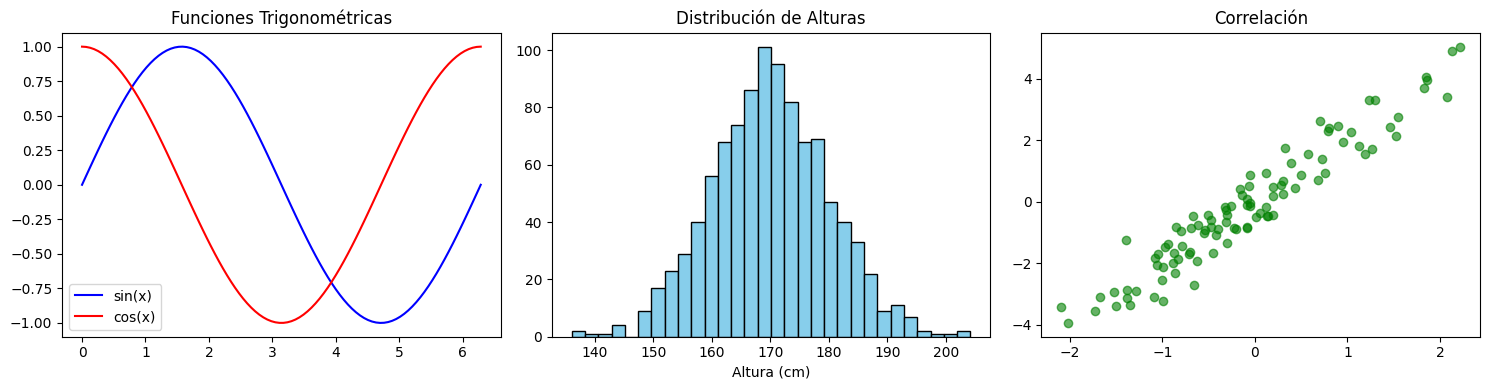

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Gráfico de línea
x = np.linspace(0, 2 * np.pi, 100)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Línea
axes[0].plot(x, np.sin(x), label="sin(x)", color="blue")
axes[0].plot(x, np.cos(x), label="cos(x)", color="red")
axes[0].set_title("Funciones Trigonométricas")
axes[0].legend()

# 2. Histograma
datos = np.random.normal(170, 10, 1000)  # Alturas simuladas
axes[1].hist(datos, bins=30, color="skyblue", edgecolor="black")
axes[1].set_title("Distribución de Alturas")
axes[1].set_xlabel("Altura (cm)")

# 3. Scatter
x_scatter = np.random.randn(100)
y_scatter = 2 * x_scatter + np.random.randn(100) * 0.5
axes[2].scatter(x_scatter, y_scatter, alpha=0.6, c="green")
axes[2].set_title("Correlación")

plt.tight_layout()
plt.show()

## Keras — Tu Primera Red Neuronal

**Keras** (integrada en TensorFlow) es la forma más accesible de construir redes neuronales en Python. Su filosofía es "diseñada para seres humanos, no para máquinas" — prioriza la claridad y la facilidad de uso sobre la flexibilidad absoluta.

Vamos a construir un clasificador de dígitos escritos a mano usando el dataset **MNIST**, que es el "Hola Mundo" del Deep Learning: un rito de paso por el que pasa todo el mundo en IA.

### ¿Qué es MNIST?

MNIST es un dataset de **70.000 imágenes** de dígitos escritos a mano (0-9), cada una de **28×28 píxeles** en escala de grises. Es tan ubicuo que la comunidad lo considera el benchmark más básico — si tu modelo no funciona con MNIST, hay un problema serio.

- **60.000 imágenes** para entrenamiento (learning)
- **10.000 imágenes** para test (evaluación)

### ¿Qué es una Red Neuronal?

![NeuralNetworkMNISTLow](https://user-images.githubusercontent.com/16117276/221560697-ff9c2629-f394-4a7a-9ec2-f8733a06df03.gif)

Una red neuronal es un modelo matemático inspirado (vagamente) en el cerebro humano. Consiste en **capas de neuronas** conectadas entre sí, donde cada conexión tiene un **peso** que el modelo aprende a ajustar durante el entrenamiento:

```
┌─────────────┐     ┌──────────────┐     ┌──────────────┐     ┌──────────────┐
│   INPUT      │     │  CAPA OCULTA │     │  CAPA OCULTA │     │    OUTPUT    │
│   (784       │────▶│  (128        │────▶│  (64         │────▶│  (10 clases) │
│   píxeles)   │     │   neuronas)  │     │   neuronas)  │     │  0,1,...,9   │
└─────────────┘     └──────────────┘     └──────────────┘     └──────────────┘
  Imagen 28x28         ReLU                  ReLU                 Softmax
```

### Conceptos clave del flujo:

1. **Input (Flatten)**: la imagen de 28×28 píxeles se "aplana" a un vector de 784 valores (cada píxel es un número entre 0 y 1 que indica la intensidad de gris).
2. **Capas ocultas (Dense + ReLU)**: transforman los datos pasándolos por funciones matemáticas (pesos × inputs + sesgo), aplicando una activación no lineal (ReLU = max(0, x)).
3. **Dropout**: durante el entrenamiento, "apaga" aleatoriamente un porcentaje de neuronas para evitar el **sobreajuste** (overfitting) — que el modelo memorice los datos en vez de aprender patrones generales.
4. **Output (Softmax)**: la última capa tiene 10 neuronas (una por dígito) y devuelve **probabilidades** que suman 1. La neurona con mayor probabilidad es la predicción del modelo.

### El ciclo de entrenamiento

```
Por cada época (pasada completa por los datos):
  Por cada batch (grupo de imágenes):
    1. Forward pass: pasar imágenes por la red → obtener predicciones
    2. Calcular loss: comparar predicciones con las etiquetas reales
    3. Backward pass: calcular cuánto debe ajustarse cada peso
    4. Actualizar pesos: el optimizador (Adam) ajusta los pesos
```

> 🧠 **No necesitáis entender las matemáticas** detrás de cada paso en este módulo — eso lo veréis en las asignaturas de Deep Learning y ML Predictivo. Lo importante es entender el **flujo conceptual** y saber usar Keras para construir modelos.

In [5]:
# Instalar TensorFlow (ya viene en Colab)
# !pip install tensorflow

import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. Cargar el dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2. Normalizar los píxeles (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

print(f"Datos de entrenamiento: {x_train.shape}")  # (60000, 28, 28)
print(f"Datos de test: {x_test.shape}")              # (10000, 28, 28)
print(f"Ejemplo de etiqueta: {y_train[0]}")          # El dígito de la primera imagen

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Datos de entrenamiento: (60000, 28, 28)
Datos de test: (10000, 28, 28)
Ejemplo de etiqueta: 5


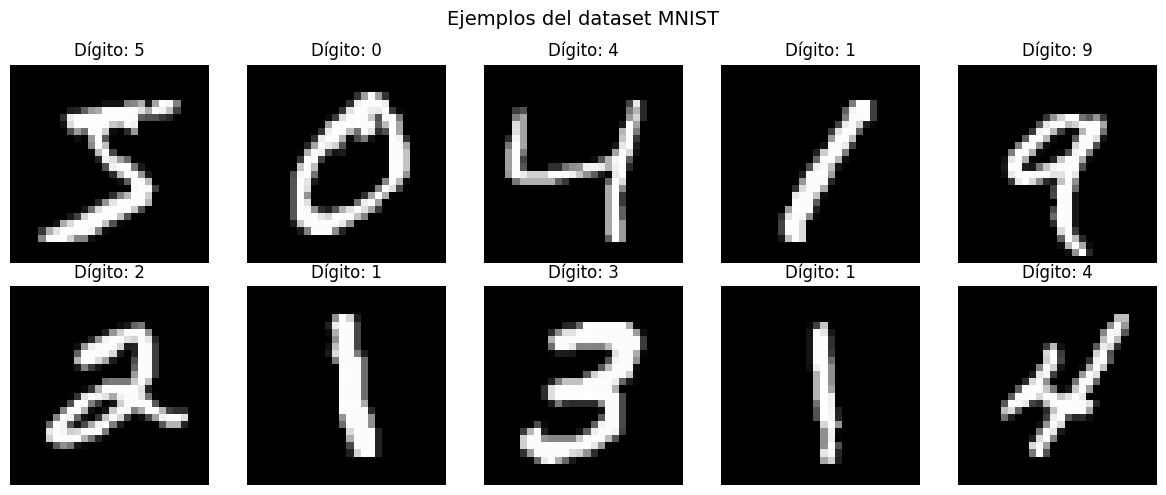

In [6]:
# Visualizar algunas imágenes del dataset
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Dígito: {y_train[i]}")
    ax.axis("off")
plt.suptitle("Ejemplos del dataset MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow import keras

# 1. Cargar y normalizar datos
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Definir la arquitectura del modelo
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

# 3. Compilar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Entrenar
print('Entrenando el modelo...')
model.fit(x_train, y_train, epochs=5)

# 5. Evaluar
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f'\nPrecisión en el set de prueba: {accuracy*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando el modelo...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9135 - loss: 0.2959
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9564 - loss: 0.1477
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9671 - loss: 0.1100
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9719 - loss: 0.0900
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9760 - loss: 0.0772
313/313 - 1s - 2ms/step - accuracy: 0.9769 - loss: 0.0719

Precisión en el set de prueba: 97.69%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


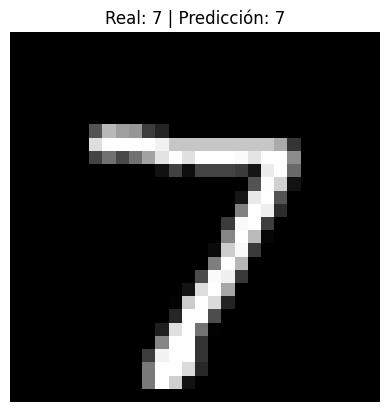

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizar una predicción
idx = 0
prediction = model.predict(x_test[idx:idx+1])
clase_predicha = np.argmax(prediction)

plt.imshow(x_test[idx], cmap='gray')
plt.title(f'Real: {y_test[idx]} | Predicción: {clase_predicha}')
plt.axis('off')
plt.show()

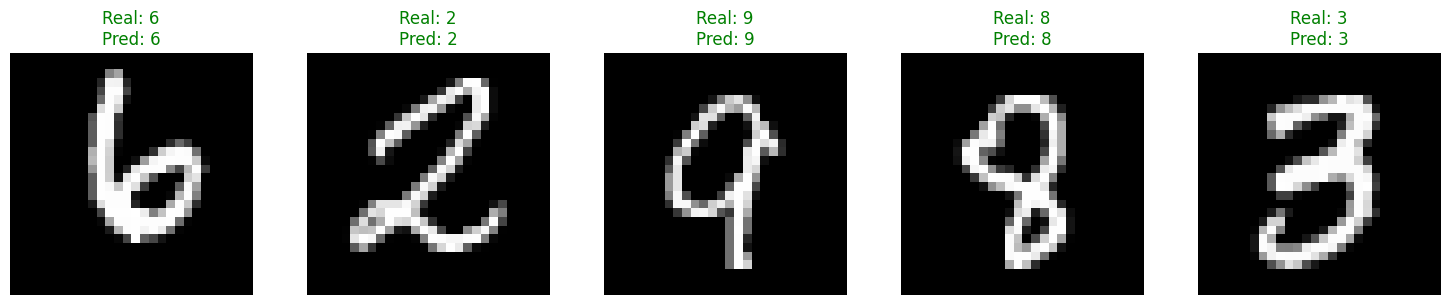

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Seleccionar 5 índices aleatorios del set de prueba
indices_aleatorios = np.random.choice(len(x_test), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, idx in enumerate(indices_aleatorios):
    # Obtener imagen y etiqueta real
    imagen = x_test[idx]
    etiqueta_real = y_test[idx]

    # Realizar predicción (añadimos la dimensión del batch: 1, 28, 28)
    prediccion_raw = model.predict(imagen.reshape(1, 28, 28), verbose=0)
    prediccion = np.argmax(prediccion_raw)

    # Visualizar
    axes[i].imshow(imagen, cmap='gray')
    color = 'green' if prediccion == etiqueta_real else 'red'
    axes[i].set_title(f"Real: {etiqueta_real}\nPred: {prediccion}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# 3. Construir el modelo
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),          # Aplanar 28×28 → 784
    keras.layers.Dense(128, activation="relu"),           # Capa oculta 1
    keras.layers.Dropout(0.2),                            # 20% dropout (evita overfitting)
    keras.layers.Dense(64, activation="relu"),            # Capa oculta 2
    keras.layers.Dense(10, activation="softmax")          # Salida: 10 clases
])

# 4. Compilar
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Ver la arquitectura
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 5. Entrenar
print("Entrenando...")
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 6. Evaluar en datos de test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy:.4f} ({accuracy*100:.1f}%)")

Entrenando...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8763 - loss: 0.4211 - val_accuracy: 0.9597 - val_loss: 0.1449
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9448 - loss: 0.1851 - val_accuracy: 0.9678 - val_loss: 0.1109
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9594 - loss: 0.1346 - val_accuracy: 0.9740 - val_loss: 0.0892
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9672 - loss: 0.1085 - val_accuracy: 0.9767 - val_loss: 0.0833
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9720 - loss: 0.0920 - val_accuracy: 0.9777 - val_loss: 0.0748
Accuracy en test: 0.9758 (97.6%)


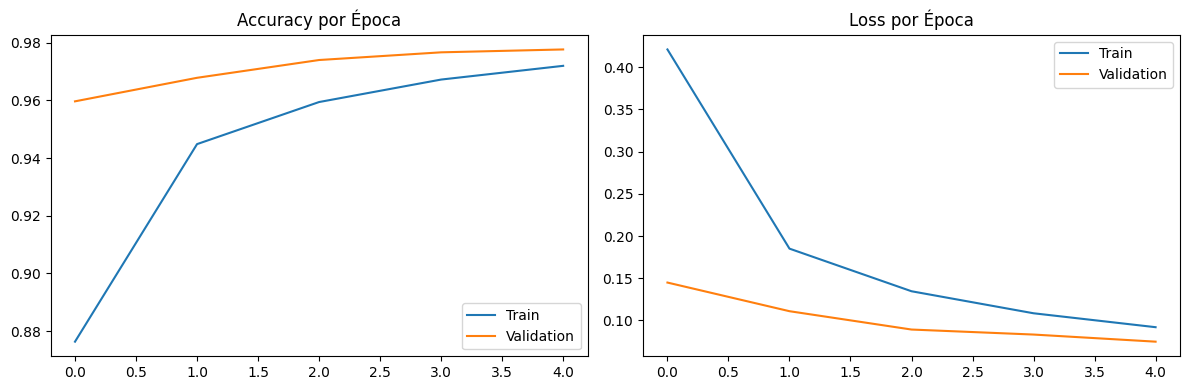

In [12]:
# 7. Visualizar el entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy por Época")
ax1.legend()

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss por Época")
ax2.legend()

plt.tight_layout()
plt.show()



### 🛠️ Ejercicio — Modifica la Red Neuronal con Prompts

Pide a Gemini:

> *"Modifica la red neuronal anterior para que tenga 3 capas ocultas (256, 128, 64 neuronas), usa BatchNormalization después de cada capa, y entrena durante 10 épocas. Muestra una comparativa de accuracy antes y después."*

Pega el resultado aquí:

Precisión del modelo anterior (5 épocas, 2 capas, sin BN): 97.58%

--- Construyendo el NUEVO modelo --- 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)


--- Entrenando el NUEVO modelo (10 épocas) ---
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8853 - loss: 0.3803 - val_accuracy: 0.9642 - val_loss: 0.1230
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9512 - loss: 0.1630 - val_accuracy: 0.9733 - val_loss: 0.0868
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9619 - loss: 0.1244 - val_accuracy: 0.9752 - val_loss: 0.0836
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9679 - loss: 0.1043 - val_accuracy: 0.9763 - val_loss: 0.0814
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9737 - loss: 0.0858 - val_accuracy: 0.9795 - val_loss: 0.0740
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9754 - loss: 0.0796 - val_accuracy: 0.9792 - val_loss: 0.0710
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9771 - loss: 0.0719 - val_accuracy: 0.9805 - val_loss: 0.0665
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step 

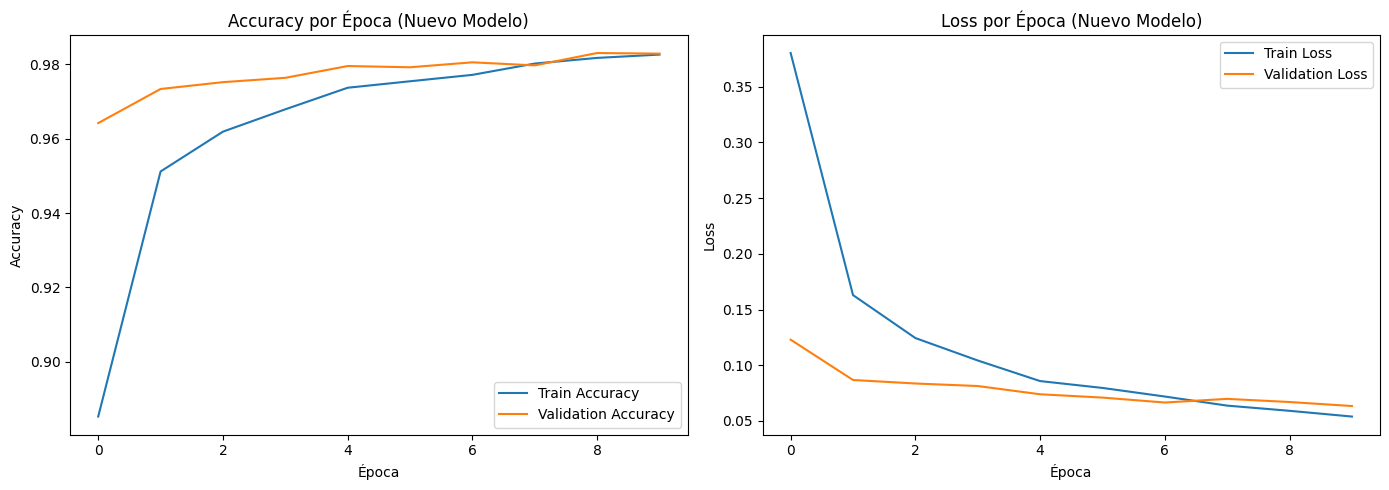

In [16]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar y normalizar datos (asegurarse de que estén disponibles)
# Estos datos ya deberían estar cargados del ejercicio anterior, pero los cargamos de nuevo por si acaso.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# --- Modelo Anterior para Comparación (si no se ha ejecutado ya) ---
# Se asume que el modelo anterior alcanzó aproximadamente 97.6% de accuracy.
# Puedes ejecutar la celda 'a8e78b2f' o 'LrX1M3QIMa2D' para obtener el valor exacto si no lo tienes a mano.
previous_model_accuracy = 0.9758 # Valor obtenido de la celda LrX1M3QIMa2D

print(f"Precisión del modelo anterior (5 épocas, 2 capas, sin BN): {previous_model_accuracy*100:.2f}%")

# --- Nuevo Modelo con las especificaciones del prompt ---
print("\n--- Construyendo el NUEVO modelo --- ")
new_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),          # Aplanar 28x28 -> 784
    keras.layers.Dense(256, activation='relu'),           # Nueva capa oculta 1 (256 neuronas)
    keras.layers.BatchNormalization(),                    # BatchNormalization
    keras.layers.Dropout(0.2),                            # Dropout
    keras.layers.Dense(128, activation='relu'),           # Capa oculta 2 (128 neuronas)
    keras.layers.BatchNormalization(),                    # BatchNormalization
    keras.layers.Dropout(0.2),                            # Dropout
    keras.layers.Dense(64, activation='relu'),            # Capa oculta 3 (64 neuronas)
    keras.layers.BatchNormalization(),                    # BatchNormalization
    keras.layers.Dropout(0.2),                            # Dropout
    keras.layers.Dense(10, activation='softmax')          # Salida: 10 clases
])

# Compilar el nuevo modelo
new_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

new_model.summary()

# Entrenar el nuevo modelo durante 10 épocas
print("\n--- Entrenando el NUEVO modelo (10 épocas) ---")
history_new = new_model.fit(
    x_train, y_train,
    epochs=10, # Modificado a 10 épocas
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Evaluar el nuevo modelo en datos de test
loss_new, accuracy_new = new_model.evaluate(x_test, y_test, verbose=0)
print(f"\nPrecisión del NUEVO modelo en test: {accuracy_new:.4f} ({accuracy_new*100:.2f}%)\n")

# --- Comparativa de Accuracy ---
print("--- Comparativa de Precisión ---")
print(f"Precisión del modelo anterior: {previous_model_accuracy*100:.2f}%")
print(f"Precisión del NUEVO modelo: {accuracy_new*100:.2f}%")

if accuracy_new > previous_model_accuracy:
    print(f"¡El nuevo modelo mejoró la precisión en {(accuracy_new - previous_model_accuracy)*100:.2f} puntos porcentuales!")
elif accuracy_new < previous_model_accuracy:
    print(f"El nuevo modelo tuvo una precisión ligeramente menor en {(previous_model_accuracy - accuracy_new)*100:.2f} puntos porcentuales.")
else:
    print("Ambos modelos tuvieron una precisión similar.")

# --- Visualizar el entrenamiento del nuevo modelo ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_new.history['accuracy'], label='Train Accuracy')
ax1.plot(history_new.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Accuracy por Época (Nuevo Modelo)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_new.history['loss'], label='Train Loss')
ax2.plot(history_new.history['val_loss'], label='Validation Loss')
ax2.set_title('Loss por Época (Nuevo Modelo)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

### Generador de Contraseñas Seguras con Criterios Configurables

Esta función `generar_contrasena_segura` crea una contraseña aleatoria y segura basada en los parámetros que le indiques, asegurándose de incluir al menos un carácter de cada tipo seleccionado para garantizar la robustez.


In [17]:
import random
import string

def generar_contrasena_segura(
    longitud: int = 12,
    incluir_mayusculas: bool = True,
    incluir_minusculas: bool = True,
    incluir_digitos: bool = True,
    incluir_simbolos: bool = True
) -> str:
    """Genera una contraseña segura con criterios configurables.

    Args:
        longitud: Longitud deseada de la contraseña. Debe ser al menos 1.
        incluir_mayusculas: Si se deben incluir letras mayúsculas.
        incluir_minusculas: Si se deben incluir letras minúsculas.
        incluir_digitos: Si se deben incluir dígitos (0-9).
        incluir_simbolos: Si se deben incluir símbolos (!@#$%^&*()).

    Returns:
        Una cadena de texto con la contraseña generada.

    Raises:
        ValueError: Si la longitud es menor a 1 o si no se selecciona ningún tipo de carácter.
    """
    if longitud < 1:
        raise ValueError("La longitud de la contraseña debe ser al menos 1.")

    caracteres_posibles = ""
    contrasena = []

    if incluir_mayusculas:
        caracteres_posibles += string.ascii_uppercase
        contrasena.append(random.choice(string.ascii_uppercase))
    if incluir_minusculas:
        caracteres_posibles += string.ascii_lowercase
        contrasena.append(random.choice(string.ascii_lowercase))
    if incluir_digitos:
        caracteres_posibles += string.digits
        contrasena.append(random.choice(string.digits))
    if incluir_simbolos:
        caracteres_posibles += string.punctuation
        contrasena.append(random.choice(string.punctuation))

    if not caracteres_posibles:
        raise ValueError("Debe seleccionar al menos un tipo de carácter para la contraseña.")

    # Rellenar el resto de la contraseña
    for _ in range(longitud - len(contrasena)):
        contrasena.append(random.choice(caracteres_posibles))

    # Mezclar la contraseña para asegurar el orden aleatorio
    random.shuffle(contrasena)
    return "".join(contrasena)


# --- Ejemplos de uso y tests ---
print("--- Generador de Contraseñas Seguras ---")

# Test 1: Contraseña básica de 12 caracteres (mayúsculas, minúsculas, dígitos, símbolos)
contrasena1 = generar_contrasena_segura()
print(f"Contraseña 1 (defecto): {contrasena1}")
assert len(contrasena1) == 12
assert any(c.isupper() for c in contrasena1)
assert any(c.islower() for c in contrasena1)
assert any(c.isdigit() for c in contrasena1)
assert any(c in string.punctuation for c in contrasena1)
print("Test 1: OK")

# Test 2: Contraseña de 8 caracteres, solo minúsculas y dígitos
contrasena2 = generar_contrasena_segura(longitud=8, incluir_mayusculas=False, incluir_simbolos=False)
print(f"Contraseña 2 (8 chars, minúsculas+dígitos): {contrasena2}")
assert len(contrasena2) == 8
assert not any(c.isupper() for c in contrasena2)
assert not any(c in string.punctuation for c in contrasena2)
assert any(c.islower() for c in contrasena2)
assert any(c.isdigit() for c in contrasena2)
print("Test 2: OK")

# Test 3: Contraseña de 20 caracteres, solo mayúsculas y símbolos
contrasena3 = generar_contrasena_segura(longitud=20, incluir_minusculas=False, incluir_digitos=False)
print(f"Contraseña 3 (20 chars, mayúsculas+símbolos): {contrasena3}")
assert len(contrasena3) == 20
assert not any(c.islower() for c in contrasena3)
assert not any(c.isdigit() for c in contrasena3)
assert any(c.isupper() for c in contrasena3)
assert any(c in string.punctuation for c in contrasena3)
print("Test 3: OK")

# Test 4: Manejo de error para longitud inválida
try:
    generar_contrasena_segura(longitud=0)
    assert False, "Debe fallar con longitud 0"
except ValueError as e:
    print(f"Test 4 (Error longitud 0): {e} - OK")

# Test 5: Manejo de error si no se selecciona ningún tipo de carácter
try:
    generar_contrasena_segura(incluir_mayusculas=False, incluir_minusculas=False, incluir_digitos=False, incluir_simbolos=False)
    assert False, "Debe fallar si no se selecciona ningún tipo de carácter"
except ValueError as e:
    print(f"Test 5 (Error sin tipos de carácter): {e} - OK")

print("\nTodos los tests de generación de contraseñas pasaron.")


--- Generador de Contraseñas Seguras ---
Contraseña 1 (defecto): i*'I!f~{s(29
Test 1: OK
Contraseña 2 (8 chars, minúsculas+dígitos): fnk8rg1k
Test 2: OK
Contraseña 3 (20 chars, mayúsculas+símbolos): /-^$VR<#{ET:$^{@H',;
Test 3: OK
Test 4 (Error longitud 0): La longitud de la contraseña debe ser al menos 1. - OK
Test 5 (Error sin tipos de carácter): Debe seleccionar al menos un tipo de carácter para la contraseña. - OK

Todos los tests de generación de contraseñas pasaron.


### Algoritmo de Dijkstra para el Camino Más Corto

El algoritmo de Dijkstra encuentra el camino más corto desde un nodo fuente a todos los demás nodos en un grafo con pesos de aristas no negativos. Funciona de manera iterativa, construyendo un conjunto de nodos para los cuales ya se ha determinado la distancia más corta desde la fuente.

**Pasos clave:**
1.  **Inicialización**: Asigna una distancia de 0 al nodo fuente y una distancia infinita a todos los demás nodos. Crea un conjunto de nodos no visitados.
2.  **Iteración**: Mientras haya nodos no visitados:
    a.  Selecciona el nodo no visitado con la distancia más pequeña desde la fuente.
    b.  Marca el nodo como visitado.
    c.  Para cada vecino del nodo seleccionado, calcula la distancia potencial a través del nodo actual. Si esta nueva distancia es menor que la distancia registrada actualmente para el vecino, actualiza la distancia del vecino.
3.  **Finalización**: Cuando todos los nodos son visitados (o la distancia al destino se ha determinado), el algoritmo termina. Las distancias finales son las distancias más cortas desde la fuente.

**Complejidad:** La complejidad de tiempo de Dijkstra es típicamente `O(E log V)` o `O(E + V log V)` cuando se implementa con un *priority queue* (cola de prioridad), donde V es el número de vértices y E es el número de aristas. Para grafos densos puede ser `O(V^2)` sin cola de prioridad.

In [7]:
import heapq

def dijkstra(graph: dict[str, dict[str, int]], start_node: str) -> tuple[dict[str, int], dict[str, str | None]]:
    """Implementa el algoritmo de Dijkstra para encontrar el camino más corto en un grafo.

    Args:
        graph: Un diccionario que representa el grafo. Las claves son los nodos
               y los valores son diccionarios de nodos vecinos con sus pesos.
               Ejemplo: {'A': {'B': 1, 'C': 4}, 'B': {'A': 1, 'C': 2, 'D': 5}}
        start_node: El nodo de inicio.

    Returns:
        Una tupla que contiene:
        - distances: Un diccionario con la distancia más corta desde start_node a cada nodo.
        - predecessors: Un diccionario para reconstruir el camino más corto.
    """
    # Distancias desde el nodo de inicio a todos los demás nodos
    distances: dict[str, int] = {node: float('inf') for node in graph}
    distances[start_node] = 0

    # Cola de prioridad para seleccionar el nodo no visitado con la menor distancia
    priority_queue: list[tuple[int, str]] = [(0, start_node)]

    # Diccionario para almacenar el predecesor de cada nodo en el camino más corto
    predecessors: dict[str, str | None] = {node: None for node in graph}

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        # Si ya encontramos un camino más corto a este nodo, lo ignoramos
        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            # Si se encuentra un camino más corto al vecino
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                predecessors[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))

    return distances, predecessors

def reconstruct_path(predecessors: dict[str, str | None], start_node: str, end_node: str) -> list[str]:
    """Reconstruye el camino más corto desde el nodo de inicio al nodo final.

    Args:
        predecessors: Diccionario de predecesores devuelto por dijkstra().
        start_node: Nodo de inicio.
        end_node: Nodo final.

    Returns:
        Una lista de nodos que forman el camino más corto, o una lista vacía si no hay camino.
    """
    path: list[str] = []
    current = end_node
    while current is not None:
        path.insert(0, current)
        current = predecessors[current]
        if current == start_node:
            path.insert(0, start_node)
            break

    # Si el camino no comienza con el start_node, significa que no hay camino
    if path and path[0] == start_node:
        return path
    return []

# --- Ejemplo de uso ---
# Definir el grafo (diccionario de adyacencia)
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'C': 2, 'D': 5},
    'C': {'A': 4, 'B': 2, 'D': 1},
    'D': {'B': 5, 'C': 1, 'E': 3},
    'E': {'D': 3}
}

start_node = 'A'
end_node = 'E'

distances, predecessors = dijkstra(graph, start_node)

print(f"Distancias más cortas desde {start_node}: {distances}")

path = reconstruct_path(predecessors, start_node, end_node)
if path:
    print(f"El camino más corto de {start_node} a {end_node} es: {' -> '.join(path)}")
    print(f"Longitud del camino: {distances[end_node]}")
else:
    print(f"No se encontró un camino de {start_node} a {end_node}.")


Distancias más cortas desde A: {'A': 0, 'B': 1, 'C': 3, 'D': 4, 'E': 7}
El camino más corto de A a E es: A -> B -> C -> D -> E
Longitud del camino: 7


---
# 🎮 Kahoot — Repaso de la Sesión 2

¡Vamos a repasar lo aprendido!

**Temas cubiertos:**
- NumPy y Pandas
- Técnicas de prompting (Chain of Thought, Role Prompting, Few-shot)
- Desarrollo agéntico y GitHub Copilot
- Redes neuronales con Keras

> El link del Kahoot se compartirá durante la clase en directo.

---
## 📚 Recursos adicionales

- [NumPy — Guía para principiantes](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [Pandas — 10 minutos para empezar](https://pandas.pydata.org/docs/user_guide/10min.html)
- [Prompt Engineering Guide](https://www.promptingguide.ai/)
- [GitHub Student Developer Pack](https://education.github.com/pack)
- [GitHub Copilot Docs](https://docs.github.com/en/copilot)
- [Keras — Tutorial oficial](https://keras.io/getting_started/)
- [MNIST Dataset](http://yann.lecun.com/exdb/mnist/)

## ⏭️ Próxima sesión

**Sesión 3: Ecosistema IA — HuggingFace, LangChain y Modelos**
- HuggingFace: Model Hub, Pipeline API, Datasets
- APIs de LLMs: consumir Gemini, OpenAI, Anthropic desde Python
- LangChain y RAG: construir un sistema de pregunta-respuesta sobre documentos
- Demo: modelos locales con Ollama